# EME Convergence for a Bent Anisotropic Waveguide (LiNbO₃)

Lithium niobate (LiNbO₃) is a key material in integrated photonics due to its large electro-optic coefficient and wide transparency window. However, it is a **uniaxial crystal**: its permittivity is described by a tensor, not a scalar. This has important consequences when the waveguide is bent.

In this notebook we:
1. Run an **FDTD** simulation of a 180° LiNbO₃ waveguide bend to obtain a reference transmittance.
2. Run **EME** simulations of the same bend with increasing numbers of cells.
3. Show that a **single EME cell overestimates transmission** and explain the physical origin.
4. Demonstrate **convergence of EME to the FDTD result** as the cell count increases.

> **Note:** This notebook uses `solver_version='emeanisotropic-0.0.0'`, a development build that adds correct anisotropic tensor treatment to bent-waveguide EME cells. Once this fix is merged into the main release, the default solver version will handle anisotropic materials correctly without any extra argument.

In [1]:
import tidy3d as td
import tidy3d.web as web

import numpy as np
import matplotlib.pyplot as plt

from tidy3d.plugins.mode import ModeSolver

18:23:46 -03 WARNING: Using canonical configuration directory at                
             '/home/filipe/.config/tidy3d'. Found legacy directory at           
             '~/.tidy3d', which will be ignored. Remove it manually or run      
             'tidy3d config migrate --delete-legacy' to clean up.               

## Physics Background: Why Anisotropy Complicates Bent-Waveguide EME

### The rotating permittivity tensor

For a z-cut LiNbO₃ slab the permittivity tensor in the lab frame is diagonal:

$$
\varepsilon_\text{lab} = \begin{pmatrix} n_o^2 & 0 & 0 \\ 0 & n_o^2 & 0 \\ 0 & 0 & n_e^2 \end{pmatrix}
$$

with $n_o \approx 2.21$ (ordinary, in-plane) and $n_e \approx 2.14$ (extraordinary, along z) at 1.55 µm.

In a **straight** waveguide propagating along x the tensor is constant — modes are pure TE or TM and propagate without cross-coupling.

In a **bent** waveguide (ring in the x-y plane) the local propagation direction rotates by an angle $\phi$ as the wave travels around the bend. From the perspective of the co-moving frame the effective tensor becomes:

$$
\varepsilon_\text{local}(\phi) = R_z(\phi)^\top \, \varepsilon_\text{lab} \, R_z(\phi)
$$

Because $n_o \neq n_e$ this rotation produces **off-diagonal terms** that grow with $\phi$. The local eigenmodes therefore continuously change as the wave travels — meaning that the quasi-TE and quasi-TM modes of the bent waveguide mix along the propagation path.

### Consequence for EME

EME divides the waveguide into $N$ cells and matches eigenmodes at each cell boundary. At every interface the two adjacent mode bases are slightly misaligned due to the incremental tensor rotation — generating partial **back-reflections** and **mode conversion**.

| EME cells | Physical picture |
|-----------|------------------|
| **1** | Entire 180° bend is one uniform section. No inter-cell interfaces → **no reflections from tensor rotation** → transmission is overestimated. |
| **few** | Tensor rotation is approximated as a staircase; dominant back-reflection is captured. |
| **many** | Staircase finely resolves the continuous rotation → **converges to FDTD**. |

The loss mechanism is not geometric bending loss (negligible at $r = 5$ µm for this waveguide) but **polarisation-state evolution** driven by the rotating anisotropy.

In [2]:
# ── Simulation parameters ──────────────────────────────────────────────────
wavelength  = 1.55          # free-space wavelength (µm)
freq0       = td.C_0 / wavelength

radius      = 5.0           # bend radius (µm)
width       = 0.6           # waveguide width (µm)
thickness   = 0.4           # waveguide thickness (µm)

num_modes   = 10            # number of modes in mode solvers
target_neff = 1.65          # target effective index for mode search
plane_size  = (9.0, 9.0)   # cross-section window size (µm)

# ── Materials ───────────────────────────────────────────────────────────────
SiO2   = td.material_library["SiO2"]["Palik_Lossless"]
LiNbO3 = td.material_library["LiNbO3"]["Zelmon1997"](1)  # (1) → z-cut orientation

# Common solver version that enables correct anisotropic treatment in EME bends
SOLVER_VERSION = 'emeanisotropic-0.0.0'

## Step 1 — FDTD Reference Simulation

We model the 180° bend as a **full ring** in the FDTD simulation:

- Geometry: outer cylinder minus inner cylinder (LiNbO₃ annulus on SiO₂)
- **Source**: `ModeSource` at the bottom of the ring `(0, −r, 0)`, launching in the +x direction with negative bend radius (the center of curvature is on the +y side of the source).
- **Monitor**: `ModeMonitor` at the top of the ring `(0, +r, 0)`, measuring the amplitudes of all guided modes travelling in the −x direction (i.e., those that have propagated 180° around the bend).
- **Boundaries**: `Absorber` on ±x to suppress re-entry of any radiation that escapes the open side of the ring; `PML` on ±y, ±z.

In [3]:
def build_fdtd_bend(
    radius=5.0,
    width=0.6,
    thickness=0.4,
    num_modes=10,
    target_neff=1.65,
    freq0=td.C_0 / 1.55,
    core_medium=LiNbO3,
    background_medium=SiO2,
    plane_size=(9.0, 9.0),
    mode_index=1,
):
    """Build an FDTD simulation of a 180-degree LiNbO3 waveguide bend.

    The geometry is a ring (annular cylinder) with a ModeSource at the
    bottom and a ModeMonitor at the top, measuring 180-degree transmission.
    """
    wavelength  = td.C_0 / freq0
    cross_sec   = (0, plane_size[0], plane_size[1])  # cross-section for mode planes

    # Bend mode specs
    # Source at bottom (0, -r, 0) going in +x: center of curvature is at +y → negative radius
    # Monitor at top  (0, +r, 0) receiving in -x: center of curvature is at -y → positive radius
    mode_spec_src = td.ModeSpec(
        num_modes=num_modes,
        target_neff=target_neff,
        bend_radius=-radius,
        bend_axis=1,
        num_pml=(12, 12),
    )
    mode_spec_mon = td.ModeSpec(
        num_modes=num_modes,
        target_neff=target_neff,
        bend_radius=radius,
        bend_axis=1,
        num_pml=(12, 12),
    )

    # Ring geometry: outer cylinder minus inner cylinder
    outer = td.Cylinder(center=(0, 0, 0), radius=radius + width / 2, length=thickness, axis=2)
    inner = td.Cylinder(center=(0, 0, 0), radius=radius - width / 2, length=thickness, axis=2)
    ring  = td.Structure(geometry=outer - inner, medium=core_medium)

    # Simulation domain — asymmetric: source side open, far side has extra room
    ring_outer      = radius + width / 2
    x_min, x_max    = -wavelength, ring_outer + 2 * wavelength
    sim_size        = (x_max - x_min, 2 * (radius + width + 2 * wavelength), plane_size[1])
    sim_center      = ((x_min + x_max) / 2, 0, 0)

    source = td.ModeSource(
        center=(0, -radius, 0),
        size=cross_sec,
        source_time=td.GaussianPulse(freq0=freq0, fwidth=0.1 * freq0),
        mode_spec=mode_spec_src,
        direction='+',
        mode_index=mode_index,
    )

    # Field monitor in the z=0 plane for visualization
    field_xy = td.FieldMonitor(
        center=(0, 0, 0),
        size=(td.inf, td.inf, 0),
        freqs=[freq0],
        name="field_xy",
    )

    # Mode amplitude monitor at the output (top of the ring)
    mode_out = td.ModeMonitor(
        center=(0, radius, 0),
        size=cross_sec,
        freqs=[freq0],
        name="mode_out",
        mode_spec=mode_spec_mon,
    )

    return td.Simulation(
        size=sim_size,
        center=sim_center,
        structures=[ring],
        sources=[source],
        monitors=[field_xy, mode_out],
        medium=background_medium,
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=30),
        run_time=5e-12,
        boundary_spec=td.BoundarySpec(
            x=td.Boundary.absorber(num_layers=160),
            y=td.Boundary.pml(),
            z=td.Boundary.pml(),
        ),
    )

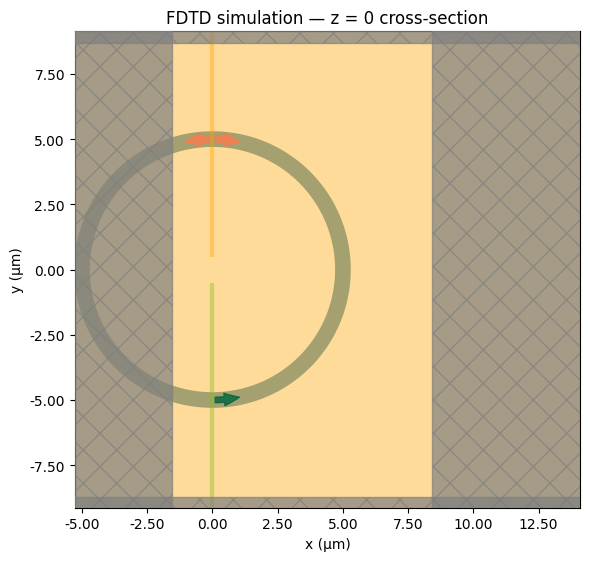

In [4]:
fdtd_sim_test = build_fdtd_bend(
    radius=radius,
    width=width,
    thickness=thickness,
    num_modes=num_modes,
    target_neff=target_neff,
    freq0=freq0,
    mode_index=0,   # fundamental quasi-TE bend mode
)

fig, ax = plt.subplots(figsize=(6, 6))
fdtd_sim_test.plot(z=0, ax=ax)
ax.set_title("FDTD simulation — z = 0 cross-section")
plt.tight_layout()
plt.show()

Mode solver simulation to make sure we will excite the correct mode.

In [5]:
ms = ModeSolver(
    simulation = fdtd_sim_test,
    mode_spec = fdtd_sim_test.sources[0].mode_spec,
    plane = fdtd_sim_test.sources[0].geometry,
    freqs = fdtd_sim_test.sources[0].source_time.freq0)

ms_data = web.run(ms)

18:23:49 -03 Loading simulation from local cache. View cached task using web UI 
             at                                                                 
             ]8;id=585573;https://tidy3d.simulation.cloud/workbench?taskId=mo-b4536948-8240-42d7-bcdc-e09dc0607cb2\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=566199;https://tidy3d.simulation.cloud/workbench?taskId=mo-b4536948-8240-42d7-bcdc-e09dc0607cb2\taskId]8;;\]8;id=585573;https://tidy3d.simulation.cloud/workbench?taskId=mo-b4536948-8240-42d7-bcdc-e09dc0607cb2\=]8;;\]8;id=165093;https://tidy3d.simulation.cloud/workbench?taskId=mo-b4536948-8240-42d7-bcdc-e09dc0607cb2\mo]8;;\]8;id=585573;https://tidy3d.simulation.cloud/workbench?taskId=mo-b4536948-8240-42d7-bcdc-e09dc0607cb2\-b4536948-8240-]8;;\
             ]8;id=585573;https://tidy3d.simulation.cloud/workbench?taskId=mo-b4536948-8240-42d7-bcdc-e09dc0607cb2\42d7-bcdc-e09dc0607cb2']8;;\.

In [6]:
# function to decide if a mode is a valid solution
def isMode(mode_data, mode_index, radius=1, freq_index=0):
    E = abs(mode_data.Ex**2 + mode_data.Ey**2 + mode_data.Ez**2)[0, :, :, freq_index, mode_index]
    center = (
        E.y.min() + (E.y.max() - E.y.min()) / 2,
        E.z.min() + (E.z.max() - E.z.min()) / 2,
    )
    bmInside = (abs(E.y - center[0]) < radius) & (abs(E.z - center[1]) < radius)
    if E.values[bmInside].sum() > E.values[~bmInside].sum():
        return True
    else:
        return False


# function to find the first valid mode
def findMode(mode_data, radius=1):
    for i in range(mode_data.Ex.shape[-1]):
        if isMode(mode_data, i, radius):
            return i
    return None

mode_index = findMode(ms_data)
print('First valid mode index:', mode_index)

First valid mode index: 4


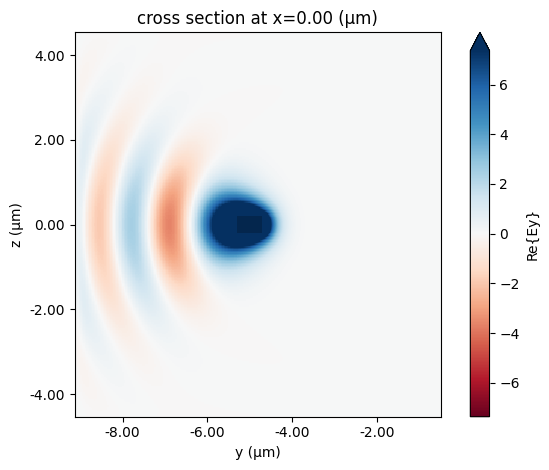

In [7]:
ms.plot_field('Ey','real',mode_index = mode_index)
plt.show()

In [8]:
fdtd_sim = build_fdtd_bend(
    radius=radius,
    width=width,
    thickness=thickness,
    num_modes=num_modes,
    target_neff=target_neff,
    freq0=freq0,
    mode_index=mode_index,   # fundamental quasi-TE bend mode
)

fdtd_data = web.run(
    fdtd_sim,
    task_name="bent_LiNbO3_FDTD",
    solver_version=SOLVER_VERSION,
)

             WARNING: Passing run options as direct arguments is deprecated. Set
             defaults via 'td.config.dispatch', 'td.config.run', and            
             'td.config.vgpu' instead.                                          

18:23:50 -03 Created task 'bent_LiNbO3_FDTD' with resource_id                   
             'fdve-34f0d460-5e9e-4f3f-a70e-be6341b38042' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=61730;https://tidy3d.simulation.cloud/workbench?taskId=fdve-34f0d460-5e9e-4f3f-a70e-be6341b38042\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=894160;https://tidy3d.simulation.cloud/workbench?taskId=fdve-34f0d460-5e9e-4f3f-a70e-be6341b38042\taskId]8;;\]8;id=61730;https://tidy3d.simulation.cloud/workbench?taskId=fdve-34f0d460-5e9e-4f3f-a70e-be6341b38042\=]8;;\]8;id=526634;https://tidy3d.simulation.cloud/workbench?taskId=fdve-34f0d460-5e9e-4f3f-a70e-be6341b38042\fdve]8;;\]8;id=61730;https://tidy3d.simulation.cloud/workbench?taskId=fdve-34f0d460-5e9e-4f3f-a70e-be6341b38042\-34f0d460-5e9]8;;\
             ]8;id=61730;https://tidy3d.simulation.cloud/workbench?taskId=fdve-34f0d460-5e9e-4f3f-a70e-be6341b38042\e-4f3f-a70e-be6341b38042']8;;\.

             Task folder: ]8;id=851732;https://tidy3d.simulation.cloud/folders/folder-431883bc-afbb-4cc8-a95f-ddfeaeeb059a\'default']8;;\.

Output()

...

Output()

18:26:09 -03 status = success

18:26:11 -03 View simulation result at                                          
             ]8;id=118760;https://tidy3d.simulation.cloud/workbench?taskId=fdve-34f0d460-5e9e-4f3f-a70e-be6341b38042\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=328858;https://tidy3d.simulation.cloud/workbench?taskId=fdve-34f0d460-5e9e-4f3f-a70e-be6341b38042\taskId]8;;\]8;id=118760;https://tidy3d.simulation.cloud/workbench?taskId=fdve-34f0d460-5e9e-4f3f-a70e-be6341b38042\=]8;;\]8;id=279295;https://tidy3d.simulation.cloud/workbench?taskId=fdve-34f0d460-5e9e-4f3f-a70e-be6341b38042\fdve]8;;\]8;id=118760;https://tidy3d.simulation.cloud/workbench?taskId=fdve-34f0d460-5e9e-4f3f-a70e-be6341b38042\-34f0d460-5e9]8;;\
             ]8;id=118760;https://tidy3d.simulation.cloud/workbench?taskId=fdve-34f0d460-5e9e-4f3f-a70e-be6341b38042\e-4f3f-a70e-be6341b38042']8;;\.

Output()

18:26:21 -03 Loading results from simulation_data.hdf5

FDTD total transmittance: T = 0.4944  (-3.06 dB)


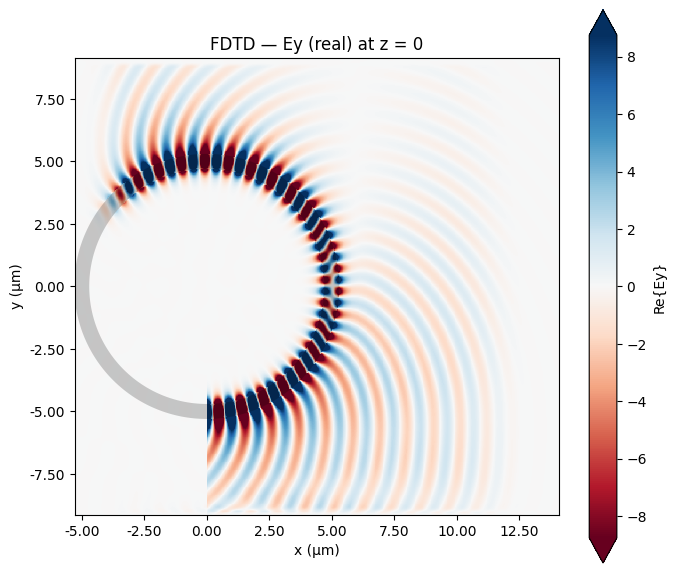

In [9]:
# Total transmitted power = sum of power in all guided output modes
amps_out = fdtd_data["mode_out"].amps.sel(direction="-")
T_fdtd   = float(np.abs(amps_out.isel(f=0,mode_index = mode_index)) ** 2)
print(f"FDTD total transmittance: T = {T_fdtd:.4f}  ({10*np.log10(T_fdtd):.2f} dB)")

# Field plot
fig, ax = plt.subplots(figsize=(7, 6))
fdtd_data.plot_field("field_xy", "Ey", "real", ax=ax)
ax.set_title("FDTD — Ey (real) at z = 0")
plt.tight_layout()
plt.show()

## Step 2 — EME Convergence Study

### EME setup for a bent waveguide

In Tidy3D's EME solver, a bent waveguide is modelled as a **straight** simulation box of length equal to the arc length ($L = \pi r$ for 180°). Each EME cell uses `bend_radius` in `EMEModeSpec` to compute the correct curved eigenmodes via conformal mapping (bend boundary conditions).

When the waveguide medium is **isotropic**, the curved eigenmodes are the same regardless of where along the arc the cross-section is taken — one EME cell is sufficient.

When the medium is **anisotropic** (LiNbO₃), the lab-frame permittivity tensor projects differently onto the local propagation frame at each position $\phi$ along the arc. Dividing the bend into $N$ cells with independently computed eigenmodes causes $N-1$ inter-cell interfaces at which mode-matching generates back-reflected amplitudes.

### Expected behaviour

- **$N = 1$**: No interfaces → no back-scattering from tensor rotation → **overestimated transmission**.
- **Increasing $N$**: Each added interface captures more of the physical reflection → transmission decreases toward the FDTD reference.
- **Large $N$**: EME converges; the result matches FDTD to within numerical precision.

We sweep $N \in \{1, 2, 3, 5, 10\}$ and compare with $T_\text{FDTD}$.

In [15]:
def build_eme_bend(fdtd_sim, num_cells):
    """Build an EME bend simulation derived from an existing FDTD simulation.

    All parameters (radius, width, thickness, num_modes, target_neff, freq0,
    plane size, and materials) are extracted from fdtd_sim, guaranteeing that
    both simulations model the exact same structure.

    Parameters
    ----------
    fdtd_sim : td.Simulation
        The FDTD bend simulation returned by build_fdtd_bend().
    num_cells : int
        Number of uniform EME cells to divide the 180-degree arc into.
    """
    src       = fdtd_sim.sources[0]
    ring_geom = fdtd_sim.structures[0].geometry  # ClipOperation: outer - inner

    # ── Extract all parameters from the FDTD simulation ────────────────────
    freq0       = src.source_time.freq0
    num_modes   = src.mode_spec.num_modes
    target_neff = src.mode_spec.target_neff
    radius      = abs(src.mode_spec.bend_radius)   # stored as negative in the source
    plane_size  = (src.size[1], src.size[2])
    num_pml     = src.mode_spec.num_pml
    grid_spec   = fdtd_sim.grid_spec

    core_medium       = fdtd_sim.structures[0].medium
    background_medium = fdtd_sim.medium

    # Width and thickness from the ring geometry (outer Cylinder - inner Cylinder)
    outer_cyl = ring_geom.geometry_a
    inner_cyl = ring_geom.geometry_b
    width     = outer_cyl.radius - inner_cyl.radius
    thickness = outer_cyl.length
    # ───────────────────────────────────────────────────────────────────────

    arc_length = np.pi * radius   # 180-degree arc

    mode_spec = td.EMEModeSpec(
        num_modes=num_modes,
        target_neff=target_neff,
        bend_radius=radius,
        bend_axis=1,
        num_pml=num_pml,
        increasing_mode_tolerance=1e-6,
    )

    # Infinite straight waveguide slab (curvature fully encoded in mode_spec)
    wg = td.Structure(
        geometry=td.PolySlab(
            axis=2,
            slab_bounds=(-thickness / 2, thickness / 2),
            vertices=[
                [-1e15, -width / 2],
                [-1e15,  width / 2],
                [ 1e15,  width / 2],
                [ 1e15, -width / 2],
            ],
        ),
        medium=core_medium,
    )

    return td.EMESimulation(
        size=(arc_length, plane_size[0], plane_size[1]),
        center=(0, 0, 0),
        structures=[wg],
        medium=background_medium,
        axis=0,
        freqs=[freq0],
        eme_grid_spec=td.EMEUniformGrid(num_cells=num_cells, mode_spec=mode_spec),
        grid_spec=grid_spec,
        store_coeffs=True,   # needed to access the full S-matrix
    )

In [16]:
num_cells_list = [1, 2, 3, 5, 10, 20]
T_eme = []

for n in num_cells_list:
    # eme_sim  = build_eme_bend(fdtd_sim, num_cells=n)
    eme_sim  = build_eme_bend(fdtd_sim, num_cells=n)
    eme_data = web.run(
        eme_sim,
        task_name=f"bent_LiNbO3_EME_N{n:02d}",
        solver_version=SOLVER_VERSION,
    )

    # Transmission = max diagonal S21 element (dominant guided mode)
    # The mode with highest transmission is the well-guided quasi-TE mode;
    # its index may shift with num_cells due to reordering, so we take the max.
    num_modes = eme_sim.eme_grid_spec.mode_spec.num_modes
    T = max(
        float(
            eme_data.smatrix.S21.isel(mode_index_in=i, mode_index_out=i, f=0).abs.item() ** 2
        )
        for i in range(num_modes)
    )
    print(f"  N = {n:2d} cells  →  T = {T:.4f}  ({10*np.log10(T):.2f} dB)")
    T_eme.append(T)

18:31:04 -03 Created task 'bent_LiNbO3_EME_N01' with resource_id                
             'eme-40977f90-435c-4e12-b253-07796ec4cb95' and task_type 'EME'.

             Tidy3D's EME solver is currently in the beta stage. Cost of EME    
             simulations is subject to change in the future.

Output()

18:31:15 -03 Estimated FlexCredit cost: 0.025. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

18:31:18 -03 status = queued

...

Output()

19:28:10 -03 status = success

Output()

19:28:20 -03 Loading results from simulation_data.hdf5

  N = 20 cells  →  T = 0.5089  (-2.93 dB)


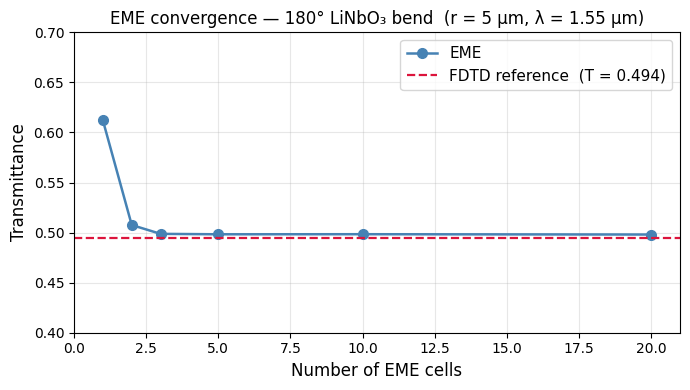


N=1   overestimates by  23.8%
N=10 error vs FDTD:    0.8%
N=20 error vs FDTD:    0.7%


In [13]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    num_cells_list, T_eme,
    "o-", color="steelblue", linewidth=1.8, markersize=7, label="EME",
)
ax.axhline(
    T_fdtd, color="crimson", linestyle="--", linewidth=1.6,
    label=f"FDTD reference  (T = {T_fdtd:.3f})",
)

ax.set_xlabel("Number of EME cells", fontsize=12)
ax.set_ylabel("Transmittance", fontsize=12)
ax.set_title("EME convergence — 180° LiNbO₃ bend  (r = 5 µm, λ = 1.55 µm)", fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0.40, 0.70)
ax.set_xlim(0, max(num_cells_list) + 1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nN={num_cells_list[0]}   overestimates by  {(T_eme[0] - T_fdtd) / T_fdtd * 100:.1f}%")
print(f"N={num_cells_list[-2]} error vs FDTD:    {abs(T_eme[-2] - T_fdtd) / T_fdtd * 100:.1f}%")
print(f"N={num_cells_list[-1]} error vs FDTD:    {abs(T_eme[-1] - T_fdtd) / T_fdtd * 100:.1f}%")

## Discussion

### Behavior with cell count

The plot shows three regimes:

| Region | Cells | Observation |
|--------|-------|-------------|
| **Single-cell** | $N = 1$ | T ≈ 0.61 — large overestimate (~24% above FDTD). |
| **Transition** | $N = 2$–$5$ | T drops sharply as the main effect is captured. |
| **Stable** | $N \geq 10$ | T ≈ 0.498, matching FDTD (T ≈ 0.495) within ~1%. |

### Why one cell is not enough

With a single EME cell the solver computes one set of curved eigenmodes for the entire 180° arc, assuming a fixed tensor orientation. At the ports, these modes are matched to straight-waveguide modes. With no internal interfaces, the system behaves close to a lossless propagator.

In reality, the eigenmodes evolve continuously as the tensor rotates. Splitting the arc into $N$ cells approximates this as discrete steps. At each step, modes are reprojected onto a new basis, introducing reflections and mode mismatch. Increasing $N$ improves this approximation.